### Import Libraries

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import cv2
import torch
import mlflow
import logging
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader
from torch import optim
from src.org_unet_parts import *
from dataloader import ACDCDataset
from utils.dice_score import dice_loss
from utils.evaluate import evaluate
%matplotlib inline

INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.21 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [2]:
log_file_name = f'./logs/acdc_attention_unet_{datetime.now().strftime("%Y%m%d%H%M%S")}.log'
logging.basicConfig(filename=log_file_name, level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f'Using device {device}')
print(f'Using device {device}')

Using device cuda


In [4]:
mlflow.login() # host: https://community.cloud.databricks.com/
mlflow.set_tracking_uri("databricks")

# Initialize logging - create a new MLflow Experiment
mlflow.set_experiment("/cmri-segmentation-of-ventricular-structures-and-myocardium")

2024/11/05 15:43:05 INFO mlflow.utils.credentials: Successfully connected to MLflow hosted tracking server! Host: https://community.cloud.databricks.com.


<Experiment: artifact_location='dbfs:/databricks/mlflow-tracking/1301949192404675', creation_time=1726678925784, experiment_id='1301949192404675', last_update_time=1730800479741, lifecycle_stage='active', name='/cmri-segmentation-of-ventricular-structures-and-myocardium', tags={'mlflow.experiment.sourceName': '/cmri-segmentation-of-ventricular-structures-and-myocardium',
 'mlflow.experimentType': 'MLFLOW_EXPERIMENT',
 'mlflow.ownerEmail': 'chinthalanka.23@cse.mrt.ac.lk',
 'mlflow.ownerId': '8299159887893237'}>

In [5]:
dir_checkpoint = Path('./models/checkpoints/attention_unet_org/')

epochs = 5
batch_size = 16
lr = 1e-5
scale = 1
amp = False

### Data Loading

In [6]:
root_dir = r'../data/ACDC/img_slices_org/'
logging.info(f'Using root_dir {root_dir}')

training_dataset = ACDCDataset(root_dir=root_dir, dataset='training')
validation_dataset = ACDCDataset(root_dir=root_dir, dataset='validation')
testing_dataset = ACDCDataset(root_dir=root_dir, dataset='testing')

logging.info(f'Training dataset size: {len(training_dataset)}')
logging.info(f'Validation dataset size: {len(validation_dataset)}')
logging.info(f'Testing dataset size: {len(testing_dataset)}')

# Load data from the dataset
train_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=False)
val_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=False)

Loaded 2084 training images
Loaded 260 validation images
Loaded 260 testing images


Keys: dict_keys(['image', 'masks', 'idx'])
Image batch shape: torch.Size([16, 224, 224, 1])
Mask batch shape: torch.Size([3, 224, 224])


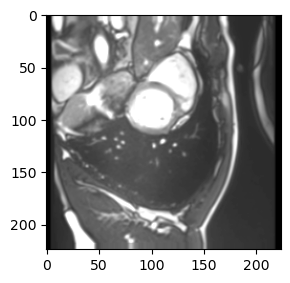

In [7]:
# Display image and mask.
sample_batch = next(iter(test_dataloader))
img_idx = 0

print(f'Keys: {sample_batch.keys()}')
print(f"Image batch shape: {sample_batch['image'].size()}")
print(f"Mask batch shape: {sample_batch['masks'][0].size()}")

img = sample_batch['image'][img_idx].squeeze().numpy()
fig = plt.figure(figsize=(3, 3))
plt.imshow(img, cmap='gray')
plt.tight_layout()
plt.show()

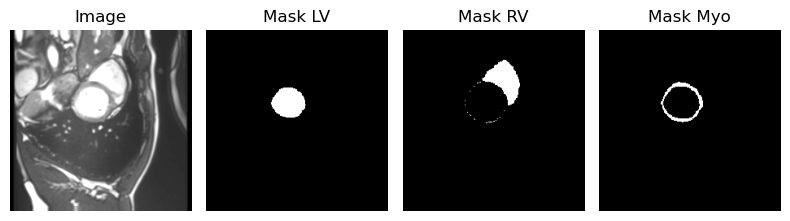

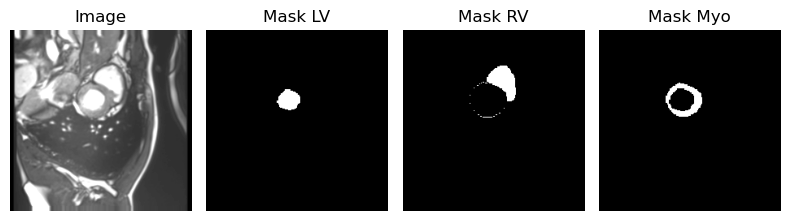

In [8]:
# Iterate through the dataset and plot the first 4 samples
n_samples_to_plot = 2

for i, sample in enumerate(test_dataloader):
    if i >= n_samples_to_plot:
        break
    
    # Extract data from the sample
    image = sample['image'][i].squeeze().numpy()  # Convert to numpy array
    msk_lv = sample['masks'][i][0].squeeze().numpy()
    msk_rv = sample['masks'][i][1].squeeze().numpy()
    msk_myo = sample['masks'][i][2].squeeze().numpy()
    
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(8, 5))
    
    # Plot the image and masks
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Image')
    axes[0].axis('off')
    
    axes[1].imshow(msk_lv, cmap='gray')
    axes[1].set_title('Mask LV')
    axes[1].axis('off')
    
    axes[2].imshow(msk_rv, cmap='gray')
    axes[2].set_title('Mask RV')
    axes[2].axis('off')
    
    axes[3].imshow(msk_myo, cmap='gray')
    axes[3].set_title('Mask Myo')
    axes[3].axis('off')
    
    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

### Attention U-Net Model

In [12]:
# Attention U-Net Model
class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        
        # Resize g1 to match x1 dimensions if necessary
        if g1.size() != x1.size():
            g1 = nn.functional.interpolate(g1, size=x1.shape[2:], mode='bilinear', align_corners=True)
        
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_channels=1, n_classes=3, bilinear=False):
        super(AttentionUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear
        
        self.encoder = nn.Sequential(
            nn.Conv2d(self.n_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.att_block = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, self.n_classes, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        enc = self.encoder(x)
        pooled = self.pool(enc)
        attn = self.att_block(pooled, enc)
        
        # Resize attn to match enc dimensions if necessary
        if attn.size() != enc.size():
            attn = nn.functional.interpolate(attn, size=enc.shape[2:], mode='bilinear', align_corners=True)
        
        dec = self.decoder(attn)
        return dec

### Model Training

In [13]:
def train_model(
        model,
        device,
        epochs: int = 5,
        batch_size: int = 1,
        learning_rate: float = 1e-5,
        save_checkpoint: bool = True,
        img_scale: float = 0.5,
        amp: bool = False,
        weight_decay: float = 1e-8,
        momentum: float = 0.999,
        gradient_clipping: float = 1.0,
):
    n_train = len(training_dataset)
    n_val = len(validation_dataset)
    
    # Start an MLflow run
    with mlflow.start_run():
        logging.info(f'''Starting training:
            Epochs:          {epochs}
            Batch size:      {batch_size}
            Learning rate:   {learning_rate}
            Training size:   {n_train}
            Validation size: {n_val}
            Checkpoints:     {save_checkpoint}
            Device:          {device.type}
            Images scaling:  {img_scale}
            Mixed Precision: {amp}
        ''')
        
        params = {
            'epochs': epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'training_set_size': n_train,
            'validation_set_size': n_val,
            'img_scale': img_scale,
            'mixed_precision': amp
        }
        
        mlflow.log_params(params)

        # Set up the optimizer, the loss, the learning rate scheduler and the loss scaling for AMP
        optimizer = optim.RMSprop(model.parameters(),
                                  lr=learning_rate, weight_decay=weight_decay, momentum=momentum, foreach=True)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=5)  # goal: maximize Dice score
        grad_scaler = torch.cuda.amp.GradScaler(enabled=amp)
        criterion = nn.CrossEntropyLoss() if model.n_classes > 1 else nn.BCEWithLogitsLoss()
        global_step = 0

        # Begin training
        for epoch in range(1, epochs + 1):
            model.train()
            epoch_loss = 0
            with tqdm(total=n_train, desc=f'Epoch {epoch}/{epochs}', unit='img') as pbar:
                for batch in train_dataloader:
                    # images, msks_lv, msks_rv, msks_myo = batch['image'], batch['mask_lv'], batch['mask_rv'], batch['mask_myo']
                    images, masks = batch['image'], batch['masks']
                    images = images.permute(0, 3, 1, 2)
                    # logging.info(f"images shape: {images.shape}")
    
                    assert images.shape[1] == model.n_channels, \
                        f'Network has been defined with {model.n_channels} input channels, ' \
                        f'but loaded images have {images.shape[1]} channels. Please check that ' \
                        'the images are loaded correctly.'
    
                    images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    true_masks = masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                    # logging.info(f"true masks shape: {true_masks.shape}")
    
                    with torch.autocast(device.type if device.type != 'mps' else 'cpu', enabled=amp):
                        # masks_pred = model(images).permute(1, 0, 2, 3)
                        masks_pred = model(images)
                        # logging.info(f"masks pred shape: {masks_pred.shape}")
                        if model.n_classes == 1:
                            loss = criterion(masks_pred.squeeze(1), true_masks.float())
                            loss += dice_loss(F.sigmoid(masks_pred.squeeze(1)), true_masks.float(), multiclass=False)
                        else:
                            loss = criterion(masks_pred, true_masks)
                            loss += dice_loss(
                                F.sigmoid(masks_pred > 0.5).float(),
                                # F.softmax(masks_pred, dim=1).float(),
                                # F.one_hot(true_masks, model.n_classes).permute(0, 3, 1, 2).float(),
                                true_masks.float(),
                                multiclass=True
                            )
    
                    optimizer.zero_grad(set_to_none=True)
                    grad_scaler.scale(loss).backward()
                    grad_scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clipping)
                    grad_scaler.step(optimizer)
                    grad_scaler.update()
    
                    pbar.update(images.shape[0])
                    global_step += 1
                    epoch_loss += loss.item()
                    pbar.set_postfix(**{'loss (batch)': loss.item()})
    
                    # Evaluation round
                    division_step = (n_train // (5 * batch_size))
                    if division_step > 0:
                        if global_step % division_step == 0:
                            val_score = evaluate(model, val_dataloader, device, amp)
                            scheduler.step(val_score)
                            logging.info('Validation Dice score: {}'.format(val_score))
    
            if save_checkpoint:
                Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
                state_dict = model.state_dict()
                # state_dict['mask_values'] = training_dataset.mask_values
                torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))
                logging.info(f'Checkpoint {epoch} saved!')
        
        # Log train and validation set Dice Scores
        train_dice_score = evaluate(model, train_dataloader, device, amp)
        val_dice_score = evaluate(model, val_dataloader, device, amp)
        
        mlflow.log_metric("train_dice_score", train_dice_score)
        mlflow.log_metric("val_dice_score", val_dice_score)
        
        logging.info('Overall Train Dice score: {}'.format(train_dice_score))
        logging.info('Overall Validation Dice score: {}'.format(val_dice_score))

### Training

In [14]:
# n_channels=3 for RGB images
# n_classes is the number of probabilities you want to get per pixel
model = AttentionUNet(n_channels=1, n_classes=3, bilinear=False)
model = model.to(memory_format=torch.channels_last)

logging.info(f'Network:\n'
                 f'\t{model.n_channels} input channels\n'
                 f'\t{model.n_classes} output channels (classes)\n'
                 f'\t{"Bilinear" if model.bilinear else "Transposed conv"} upscaling')

model.to(device=device)

try:
    train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )
except torch.cuda.OutOfMemoryError:
    logging.error('Detected OutOfMemoryError! '
                  'Enabling checkpointing to reduce memory usage, but this slows down training. '
                  'Consider enabling AMP (--amp) for fast and memory efficient training')
    torch.cuda.empty_cache()
    model.use_checkpointing()
    train_model(
        model=model,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=lr,
        device=device,
        img_scale=scale,
        amp=amp
    )

Epoch 5/5: 100%|██████████| 2084/2084 [02:33<00:00, 13.59img/s, loss (batch)=1]   


### Testing and Evaluation

In [15]:
def visualize_prediction(model, dataloader, device, sample_idx=0, img_idx=0):
    model.eval()
    with torch.no_grad():
        for i, sample in enumerate(dataloader):
            if i == sample_idx:
                # Extract data from the sample
                images = sample['image']
                true_masks = sample['masks']
                print(f'images shape: {images.shape}')
                print(f'true masks shape: {true_masks.shape}')
                images = images.permute(0, 3, 1, 2)
                images = images.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)
                true_masks = true_masks.to(device=device, dtype=torch.float32, memory_format=torch.channels_last)

                outputs = model(images)

                # Apply sigmoid to convert logits to probabilities, then threshold
                preds = torch.sigmoid(outputs)
                preds = (preds > 0.5).float()  # Convert to binary masks (0 or 1)
                preds = preds.cpu().numpy()
                print(f'preds shape: {preds.shape}')

                fig, ax = plt.subplots(2, 4, figsize=(15, 8))
                ax[0][0].imshow(images[img_idx].cpu().squeeze(), cmap='gray')
                ax[0][0].set_title('Input Image')

                ax[0][1].imshow(true_masks[img_idx][0].cpu().squeeze(), cmap='gray')
                ax[0][1].set_title('True LV')

                ax[0][2].imshow(true_masks[img_idx][1].cpu().squeeze(), cmap='gray')
                ax[0][2].set_title('True RV')

                ax[0][3].imshow(true_masks[img_idx][2].cpu().squeeze(), cmap='gray')
                ax[0][3].set_title('True MYO')

                ax[1][0].imshow(images[img_idx].cpu().squeeze(), cmap='gray')
                ax[1][0].set_title('Input Image')

                ax[1][1].imshow(preds[img_idx][0], cmap='gray')
                ax[1][1].set_title('Pred LV')

                ax[1][2].imshow(preds[img_idx][1], cmap='gray')
                ax[1][2].set_title('Pred RV')

                ax[1][3].imshow(preds[img_idx][2], cmap='gray')
                ax[1][3].set_title('Pred MYO')



                plt.show()
                break  # Visualize only one image
            else:
                continue

images shape: torch.Size([16, 224, 224, 1])
true masks shape: torch.Size([16, 3, 224, 224])
preds shape: (16, 3, 224, 224)


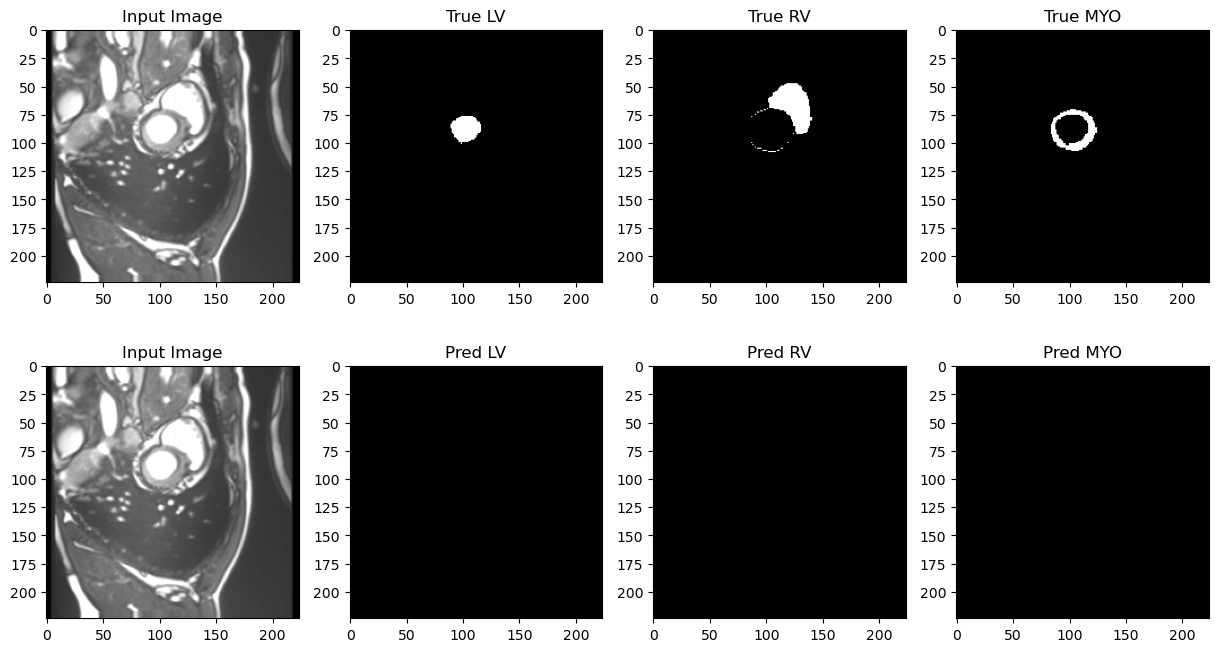

In [16]:
visualize_prediction(model, test_dataloader, device, sample_idx=0, img_idx = 15)

In [ ]:
torch.cuda.empty_cache()